# 14 — Data drift: mock → real (Phase 5c)

When the **real GTA recordings** replaced the **mock** baseline (mouse-on-desktop, idle keystrokes), how much did each feature actually move? This notebook *measures* that shift instead of assuming it — the exact evidence that justified retraining every model on real data.

Two complementary metrics, one per question (full plain-English explanation in [`docs/MONITORING.md`](../docs/MONITORING.md)):

- **KS test** — *is the change statistically significant?* The largest vertical gap between the two cumulative distributions (the KS statistic, 0–1) plus a p-value. p < 0.05 → the distributions differ.
- **PSI** (Population Stability Index) — *how big is the shift, on an interpretable scale?* Bins the reference into deciles and sums `(cur% − ref%)·ln(cur%/ref%)`. Rule of thumb: **< 0.1** none, **0.1–0.25** moderate, **> 0.25** significant.

The tool itself is `pipeline/monitoring/drift.py` (`python -m pipeline.monitoring.drift`, 13 tests). Here we run it and *visualise* the result.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS
from pipeline.monitoring.drift import (
    PSI_MODERATE,
    PSI_SIGNIFICANT,
    compute_drift_report,
)

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

mock_path = ROOT / "data" / "processed" / "features_mock_baseline.parquet"
real_path = ROOT / "data" / "processed" / "features.parquet"
have_raw = mock_path.exists() and real_path.exists()

if have_raw:
    mock_df = pd.read_parquet(mock_path)
    real_df = pd.read_parquet(real_path)
    report = compute_drift_report(mock_df, real_df, FEATURE_COLS)
    print(f"Computed drift live: mock={len(mock_df)} windows vs real={len(real_df)} windows")
else:
    # Fresh clone without the local mock snapshot → use the committed report.
    mock_df = real_df = None
    report = pd.read_csv(ROOT / "reports" / "drift_mock_vs_real.csv")
    print("Loaded committed report (local feature parquets not present)")

report.head(8).round(3)

Computed drift live: mock=59 windows vs real=267 windows


,feature,ks_stat,ks_pvalue,ks_drifted,psi,psi_severity,n_ref,n_cur
0,wasd_rhythm,0.789,0.0,True,9.367,significant,19,89
1,speed_mean,0.610,0.0,True,7.954,significant,59,248
2,speed_std,0.610,0.0,True,7.921,significant,59,248
3,accel_std,0.610,0.0,True,7.680,significant,59,248
4,accel_mean,0.585,0.0,True,6.614,significant,59,248
5,event_rate,0.608,0.0,True,5.074,significant,59,267
6,mouse_curvature_std,0.528,0.0,True,1.458,significant,59,248
7,jitter,0.392,0.0,True,1.155,significant,59,248


## The headline

Almost every feature moved — and several moved *enormously*. That is the empirical proof the mock baseline was unrepresentative of real gameplay, and that the Phase 1–4 numbers measured on mock data were data-limited baselines, not final results.

In [2]:
n_sig = int((report["psi_severity"] == "significant").sum())
n_mod = int((report["psi_severity"] == "moderate").sum())
n_none = int((report["psi_severity"] == "none").sum())
print(f"{len(report)} features: {n_sig} significant, {n_mod} moderate, {n_none} no-shift")
print("\nTop movers by PSI:")
print(report.sort_values("psi", ascending=False).head(5)[["feature", "psi", "ks_stat", "psi_severity"]].to_string(index=False))

25 features: 20 significant, 3 moderate, 2 no-shift

Top movers by PSI:
    feature      psi  ks_stat psi_severity
wasd_rhythm 9.367267 0.789474  significant
 speed_mean 7.954376 0.610169  significant
  speed_std 7.921074 0.610169  significant
  accel_std 7.679850 0.610169  significant
 accel_mean 6.613603 0.585156  significant


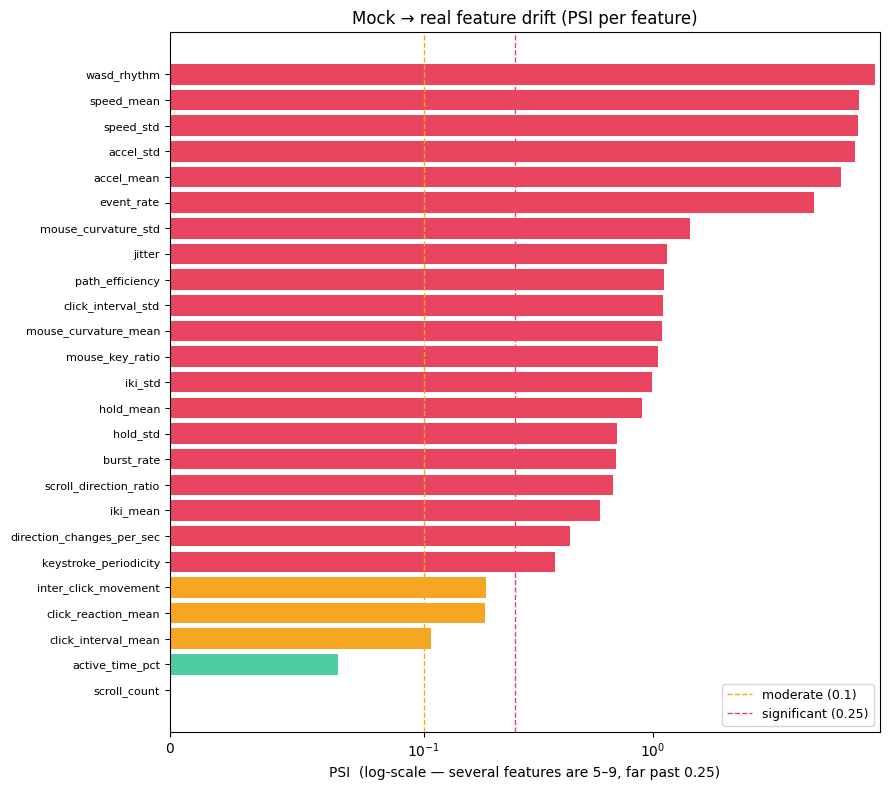

In [3]:
# PSI per feature, sorted, coloured by severity
r = report.sort_values("psi", ascending=True)
colors = {"none": "#4ecca3", "moderate": "#f5a623", "significant": "#e94560"}
bar_colors = [colors.get(s, "#888") for s in r["psi_severity"]]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(r["feature"], r["psi"], color=bar_colors)
ax.axvline(PSI_MODERATE, color="#f5a623", linestyle="--", linewidth=1, label=f"moderate ({PSI_MODERATE})")
ax.axvline(PSI_SIGNIFICANT, color="#e94560", linestyle="--", linewidth=1, label=f"significant ({PSI_SIGNIFICANT})")
ax.set_xlabel("PSI  (log-scale — several features are 5–9, far past 0.25)")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_title("Mock → real feature drift (PSI per feature)")
ax.legend(loc="lower right", fontsize=9)
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
fig.savefig(FIG / "phase5c_psi_bars.png", dpi=110, bbox_inches="tight")
plt.show()

## KS, visually — the cumulative-distribution gap

The KS statistic is the single widest vertical gap between two cumulative distribution curves. Plotting both ECDFs for the worst-drifting feature makes the metric concrete: the bigger the gap, the more the distributions disagree.

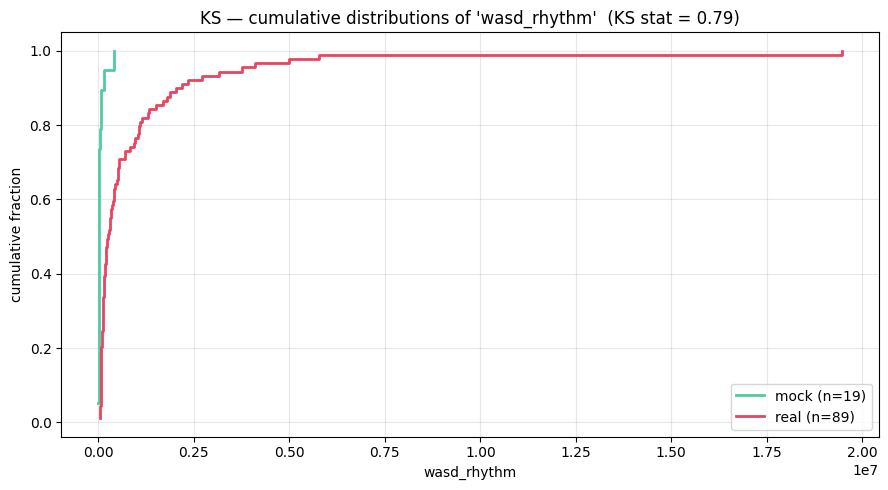

In [4]:
top_feat = report.sort_values("psi", ascending=False)["feature"].iloc[0]

if have_raw:
    a = mock_df[top_feat].dropna().to_numpy()
    b = real_df[top_feat].dropna().to_numpy()

    def ecdf(v):
        v = np.sort(v)
        return v, np.arange(1, len(v) + 1) / len(v)

    xa, ya = ecdf(a)
    xb, yb = ecdf(b)
    ks_stat = float(report.loc[report["feature"] == top_feat, "ks_stat"].iloc[0])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.step(xa, ya, where="post", color="#4ecca3", linewidth=2, label=f"mock (n={len(a)})")
    ax.step(xb, yb, where="post", color="#e94560", linewidth=2, label=f"real (n={len(b)})")
    ax.set_xlabel(top_feat)
    ax.set_ylabel("cumulative fraction")
    ax.set_title(f"KS — cumulative distributions of '{top_feat}'  (KS stat = {ks_stat:.2f})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG / "phase5c_ks_cdf.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("Raw feature parquets not present — skipping ECDF overlay (committed report only).")

## What actually moved — distribution overlays

The most intuitive view: the mock vs real histograms of the top-drifting features side by side. These are exactly the dimensions real gameplay exercises that idle desktop mouse never did — WASD movement rhythm, real aiming speed/acceleration, event rate.

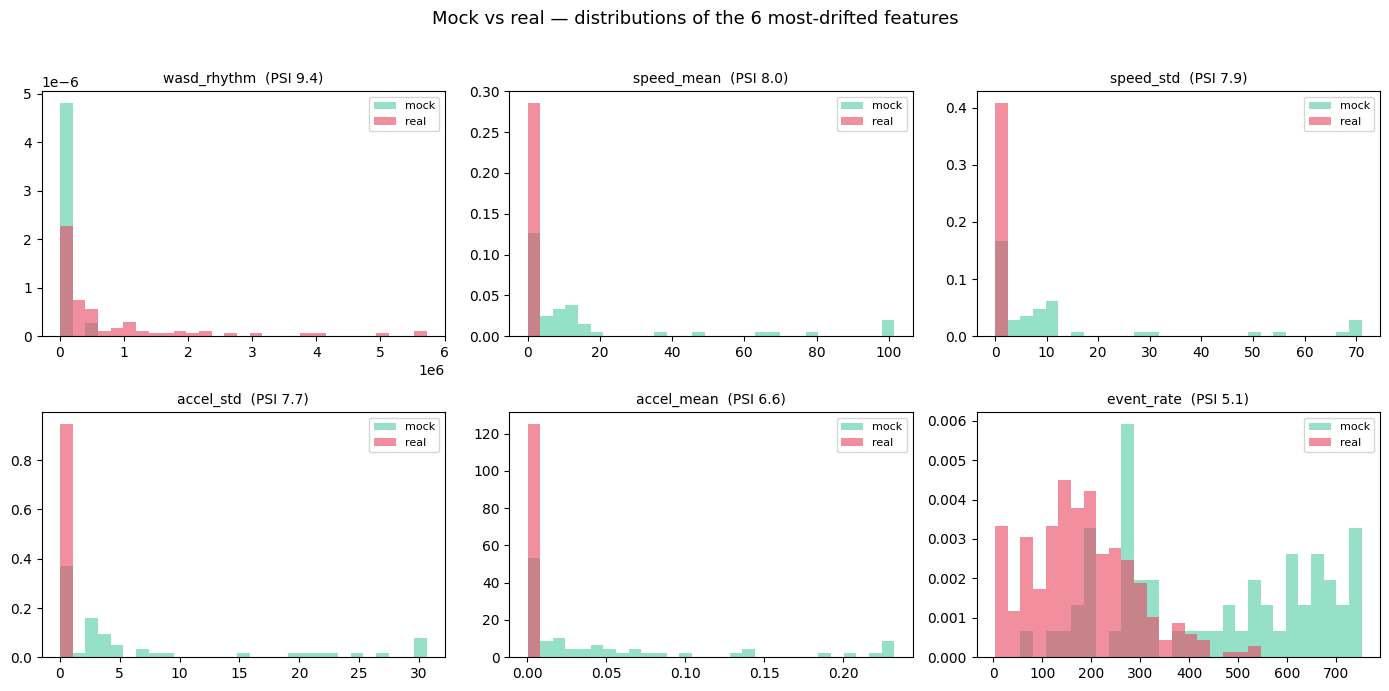

In [5]:
if have_raw:
    feats = report.sort_values("psi", ascending=False)["feature"].head(6).tolist()
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, feat in zip(axes.ravel(), feats):
        a = mock_df[feat].dropna().to_numpy()
        b = real_df[feat].dropna().to_numpy()
        lo = float(np.nanpercentile(np.concatenate([a, b]), 1))
        hi = float(np.nanpercentile(np.concatenate([a, b]), 99))
        bins = np.linspace(lo, hi, 30) if hi > lo else 30
        ax.hist(np.clip(a, lo, hi), bins=bins, density=True, alpha=0.6, color="#4ecca3", label="mock")
        ax.hist(np.clip(b, lo, hi), bins=bins, density=True, alpha=0.6, color="#e94560", label="real")
        psi_v = float(report.loc[report["feature"] == feat, "psi"].iloc[0])
        ax.set_title(f"{feat}  (PSI {psi_v:.1f})", fontsize=10)
        ax.legend(fontsize=8)
    fig.suptitle("Mock vs real — distributions of the 6 most-drifted features", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(FIG / "phase5c_distributions.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("Raw feature parquets not present — skipping distribution overlays.")

## Interpretation

- **20 / 25 features drifted significantly.** Real gameplay genuinely exercises behaviour the mock data never did — `wasd_rhythm`, `speed_*`, `accel_*`, `event_rate` lead the list.
- **This is why we retrained.** Drift detection turned "the mock numbers probably don't transfer" into a measured fact per feature — the trigger for the full real-data runbook (LSTM-AE retrain, re-benchmark), not a guess.
- **KS vs PSI disagreements are expected at this N.** With only 59 mock vs ~250 real windows, a feature can show a huge PSI but a non-significant KS p-value (small samples). Reporting both tells the fuller story — see the few rows where `ks_drifted` is False but PSI is high.

**Operationally:** `python -m pipeline.monitoring.drift --reference <baseline> --current <new>` is the same check to re-run whenever a new batch of recordings lands, to decide if the live model has gone stale. Caveat: 3 players / 18 real sessions — directional, not a population-level guarantee. Figures: `reports/figures/phase5c_*.png`.